In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from pathlib import Path

csv_name = "household_data_15min_singleindex.csv"

csv_path = None
for root in [Path.cwd(), *Path.cwd().parents]:
	candidate = root / "data" / csv_name
	if candidate.exists():
		csv_path = candidate
		break

if csv_path is None:
	raise FileNotFoundError(f"Could not find {csv_name} in the current folder or any parent folder.")

df = pd.read_csv(csv_path)
df.head()

,utc_timestamp,cet_cest_timestamp,DE_KN_industrial1_grid_import,DE_KN_industrial1_pv_1,DE_KN_industrial1_pv_2,DE_KN_industrial2_grid_import,DE_KN_industrial2_pv,DE_KN_industrial2_storage_charge,DE_KN_industrial2_storage_decharge,DE_KN_industrial3_area_offices,...,DE_KN_residential5_refrigerator,DE_KN_residential5_washing_machine,DE_KN_residential6_circulation_pump,DE_KN_residential6_dishwasher,DE_KN_residential6_freezer,DE_KN_residential6_grid_export,DE_KN_residential6_grid_import,DE_KN_residential6_pv,DE_KN_residential6_washing_machine,interpolated
0,2014-12-11T17:45:00Z,2014-12-11T18:45:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-12-11T18:00:00Z,2014-12-11T19:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-12-11T18:15:00Z,2014-12-11T19:15:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014-12-11T18:30:00Z,2014-12-11T19:30:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-12-11T18:45:00Z,2014-12-11T19:45:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing values by percentage

In [4]:
pd.set_option('display.max_rows', None)

missing_pct = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
print(missing_pct)

DE_KN_public2_grid_import              97.08
DE_KN_public1_grid_import              88.17
DE_KN_industrial2_storage_charge       74.64
DE_KN_industrial2_storage_decharge     74.64
DE_KN_residential2_freezer             73.34
DE_KN_industrial3_ev                   72.88
DE_KN_residential4_refrigerator        72.01
DE_KN_industrial2_grid_import          70.67
DE_KN_industrial3_grid_import          70.07
DE_KN_residential3_grid_import         69.04
DE_KN_industrial2_pv                   68.79
DE_KN_residential4_washing_machine     68.12
DE_KN_residential4_heat_pump           67.99
DE_KN_residential4_dishwasher          67.18
DE_KN_residential1_freezer             66.47
DE_KN_residential6_dishwasher          63.43
DE_KN_industrial3_refrigerator         62.95
DE_KN_industrial3_machine_3            62.66
DE_KN_industrial3_dishwasher           62.66
DE_KN_industrial3_pv_roof              62.66
DE_KN_industrial3_machine_2            62.66
DE_KN_industrial3_machine_1            62.66
DE_KN_indu

Here we are going to do an analysis of all the households available to determine which household will give us the best baseline to train our models and define our research questions.


In [5]:
# Convert timestamp
df["cet_cest_timestamp"] = pd.to_datetime(df["cet_cest_timestamp"], utc=True)

results = []

for i in range(1, 7):
    prefix = f"DE_KN_residential{i}"
    cols = [c for c in df.columns if c.startswith(prefix)]

    if not cols:
        continue

    subset = df[cols].copy()

    # 1. Number of features
    num_features = len(cols)

    # 2. Missing values
    total_missing = subset.isnull().sum().sum()

    # 3. Percentage missing
    total_values = subset.shape[0] * subset.shape[1]
    missing_pct = (total_missing / total_values) * 100

    # 4. Variability (std of grid_import)
    grid_col = f"{prefix}_grid_import"
    std_val = subset[grid_col].std() if grid_col in subset.columns else None

    # 5. Time coverage (non-null rows for grid_import)
    non_null_count = subset[grid_col].notnull().sum() if grid_col in subset.columns else 0

    results.append({
        "household": f"residential{i}",
        "num_features": num_features,
        "missing_values": total_missing,
        "missing_%": round(missing_pct, 2),
        "std_dev": round(std_val, 2) if std_val else None,
        "non_null_rows": non_null_count
    })

results_df = pd.DataFrame(results)

print("\n=== Residential Comparison ===")
print(results_df.sort_values(by="missing_%"))


print("\n=== Suggested Best Household ===")

best = results_df.sort_values(
    by=["missing_%", "num_features", "std_dev"],
    ascending=[True, False, False]
).iloc[0]

print(best)



=== Residential Comparison ===
      household  num_features  missing_values  missing_%  std_dev  \
2  residential3             8          415703      33.78  1516.94   
4  residential5             4          245453      39.90  2612.40   
1  residential2             5          410110      53.33  1276.66   
5  residential6             7          574754      53.38  1841.65   
3  residential4             9          785893      56.77  2777.28   
0  residential1             6          554060      60.04  2650.34   

   non_null_rows  
2          47612  
4         123211  
1          63190  
5          86133  
3          81435  
0          63487  

=== Suggested Best Household ===
household         residential3
num_features                 8
missing_values          415703
missing_%                33.78
std_dev                1516.94
non_null_rows            47612
Name: 2, dtype: object


Residential 3 the best out of all, having all appliance with around 20% of missing data. Only grid_import has 69% of missing data which is not that good

Now checking if its one continuos block of missing values

In [6]:
s = df['DE_KN_residential3_grid_import']
mask = s.notnull()
groups = (mask != mask.shift()).cumsum()
valid_windows = df[mask].groupby(groups[mask]).agg({
    'utc_timestamp': ['min', 'max', 'count']
})
valid_windows.columns = ['start', 'end', 'length']
valid_windows = valid_windows.sort_values('length', ascending=False)

print(valid_windows.head())

                                               start                   end  \
DE_KN_residential3_grid_import                                               
2                               2016-02-28T17:15:00Z  2017-07-08T16:00:00Z   

                                length  
DE_KN_residential3_grid_import          
2                                47612  


Missing data is not scattered but one continuous window from From 2016-02-28 → 2017-07-08  of 1.36 years

In [7]:
cols = [col for col in df.columns if "DE_KN_residential3" in col]
cols = ["utc_timestamp"] + cols

df_r3 = df[cols].copy()

In [8]:
df_r3 = df_r3[
    (df_r3["utc_timestamp"] >= "2016-02-28T17:15:00Z") &
    (df_r3["utc_timestamp"] <= "2017-07-08T16:00:00Z")
].copy()

convert to datetime object

In [9]:
df_r3["utc_timestamp"] = pd.to_datetime(df_r3["utc_timestamp"])
df_r3 = df_r3.sort_values("utc_timestamp")
df_r3 = df_r3.set_index("utc_timestamp")

converting cumulative energy to enery usage per timeframe

In [10]:
df_usage = df_r3.diff().copy()
df_usage = df_usage.dropna()
df_usage[df_usage < 0] = 0

In [11]:
df_usage.describe()

,DE_KN_residential3_circulation_pump,DE_KN_residential3_dishwasher,DE_KN_residential3_freezer,DE_KN_residential3_grid_export,DE_KN_residential3_grid_import,DE_KN_residential3_pv,DE_KN_residential3_refrigerator,DE_KN_residential3_washing_machine
count,47611.000000,47611.000000,47611.000000,47611.000000,47611.000000,47611.000000,47611.000000,47611.000000
mean,0.014032,0.008371,0.003219,0.099343,0.121360,0.152817,0.006144,0.014764
std,0.007694,0.044632,0.007381,0.189538,3.686171,0.793327,0.005391,0.060907
min,0.001000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.007000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.016000,0.001000,0.000000,0.000000,0.060000,0.000000,0.006000,0.000000
75%,0.018000,0.001000,0.001000,0.100000,0.151000,0.206000,0.012000,0.000000
max,0.036000,0.446000,0.036000,0.950000,803.940000,73.306000,0.017000,0.522000


In [12]:
idx = df_usage["DE_KN_residential3_grid_import"].idxmax()

df_r3.loc[idx - pd.Timedelta(minutes=30): idx + pd.Timedelta(minutes=30),
          "DE_KN_residential3_grid_import"]

utc_timestamp
2017-07-08 15:30:00+00:00    4974.125
2017-07-08 15:45:00+00:00    4974.189
2017-07-08 16:00:00+00:00    5778.129
Name: DE_KN_residential3_grid_import, dtype: float64

removing impossible values. 10 Kwh is already suspicious for a residential household for 15 minute interval

In [13]:
df_usage = df_usage[
    df_usage["DE_KN_residential3_grid_import"] < 10
]
df_usage.describe()

,DE_KN_residential3_circulation_pump,DE_KN_residential3_dishwasher,DE_KN_residential3_freezer,DE_KN_residential3_grid_export,DE_KN_residential3_grid_import,DE_KN_residential3_pv,DE_KN_residential3_refrigerator,DE_KN_residential3_washing_machine
count,47610.000000,47610.000000,47610.000000,47610.000000,47610.000000,47610.000000,47610.000000,47610.000000
mean,0.014032,0.008371,0.003219,0.099345,0.104477,0.152820,0.006144,0.014764
std,0.007694,0.044632,0.007381,0.189539,0.127981,0.793335,0.005391,0.060908
min,0.001000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.007000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.016000,0.001000,0.000000,0.000000,0.060000,0.000000,0.006000,0.000000
75%,0.018000,0.001000,0.001000,0.100000,0.151000,0.206000,0.012000,0.000000
max,0.036000,0.446000,0.036000,0.950000,1.280000,73.306000,0.017000,0.522000


Plots

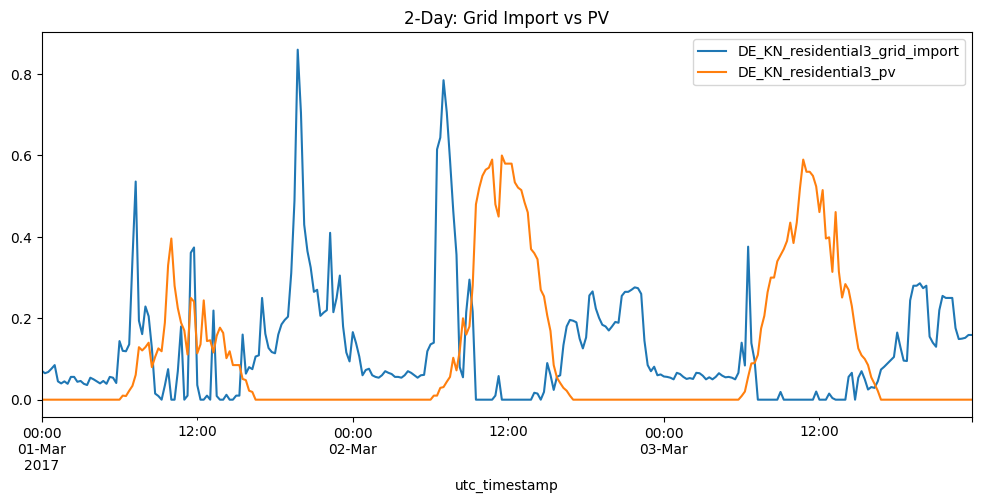

In [14]:
df_usage.loc["2017-03-01":"2017-03-03",
             ['DE_KN_residential3_grid_import',
              'DE_KN_residential3_pv']].plot(figsize=(12,5))
plt.title("2-Day: Grid Import vs PV")
plt.show()

This plot shows the short-term interaction between solar generation and grid electricity usage. PV generation follows a clear daily pattern, with zero output during nighttime and peaks during midday. Grid import, however, fluctuates independently with several spikes. While there are periods where grid import decreases during high PV generation, the relationship is weak, indicating that the household does not consistently utilize solar energy to reduce grid dependency.

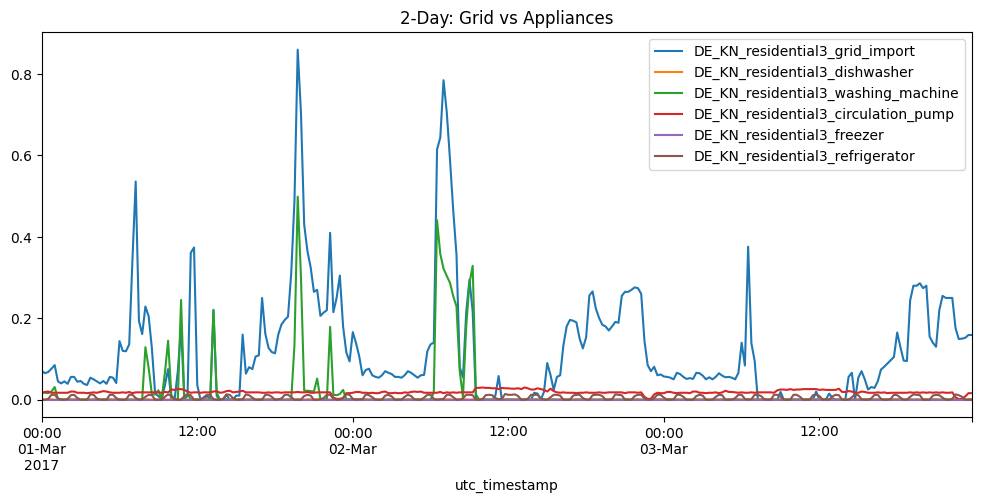

In [37]:
df_usage.loc["2017-03-01":"2017-03-03",
             ['DE_KN_residential3_grid_import',
              'DE_KN_residential3_dishwasher',
              'DE_KN_residential3_washing_machine','DE_KN_residential3_circulation_pump','DE_KN_residential3_freezer','DE_KN_residential3_refrigerator'
              ]].plot(figsize=(12,5))
plt.title("2-Day: Grid vs Appliances")
plt.show()

This plot highlights the impact of individual appliances on total electricity consumption. Peaks in grid import often coincide with spikes in appliance usage, particularly the washing machine, indicating that such devices significantly contribute to short-term demand increases. The dishwasher appears less frequently, suggesting lower usage or weaker influence. Overall, appliance usage drives consumption variability.

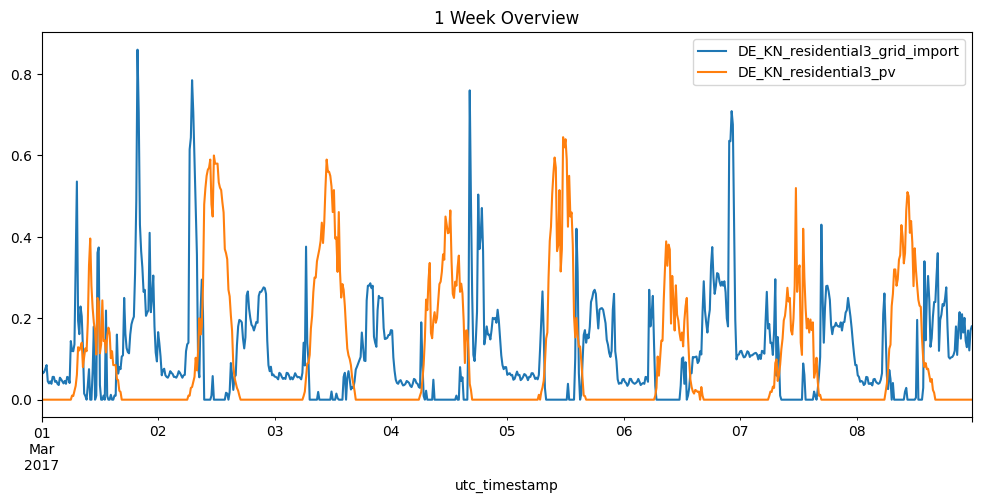

In [16]:
df_usage.loc["2017-03-01":"2017-03-08",
             ['DE_KN_residential3_grid_import',
              'DE_KN_residential3_pv']].plot(figsize=(12,5))
plt.title("1 Week Overview")
plt.show()

The weekly view provides a broader perspective on energy patterns. PV generation shows a consistent daily cycle, while grid import varies irregularly without a clear weekly trend. This suggests that solar generation is predictable, whereas electricity consumption is largely influenced by user behavior rather than repeating weekly patterns.

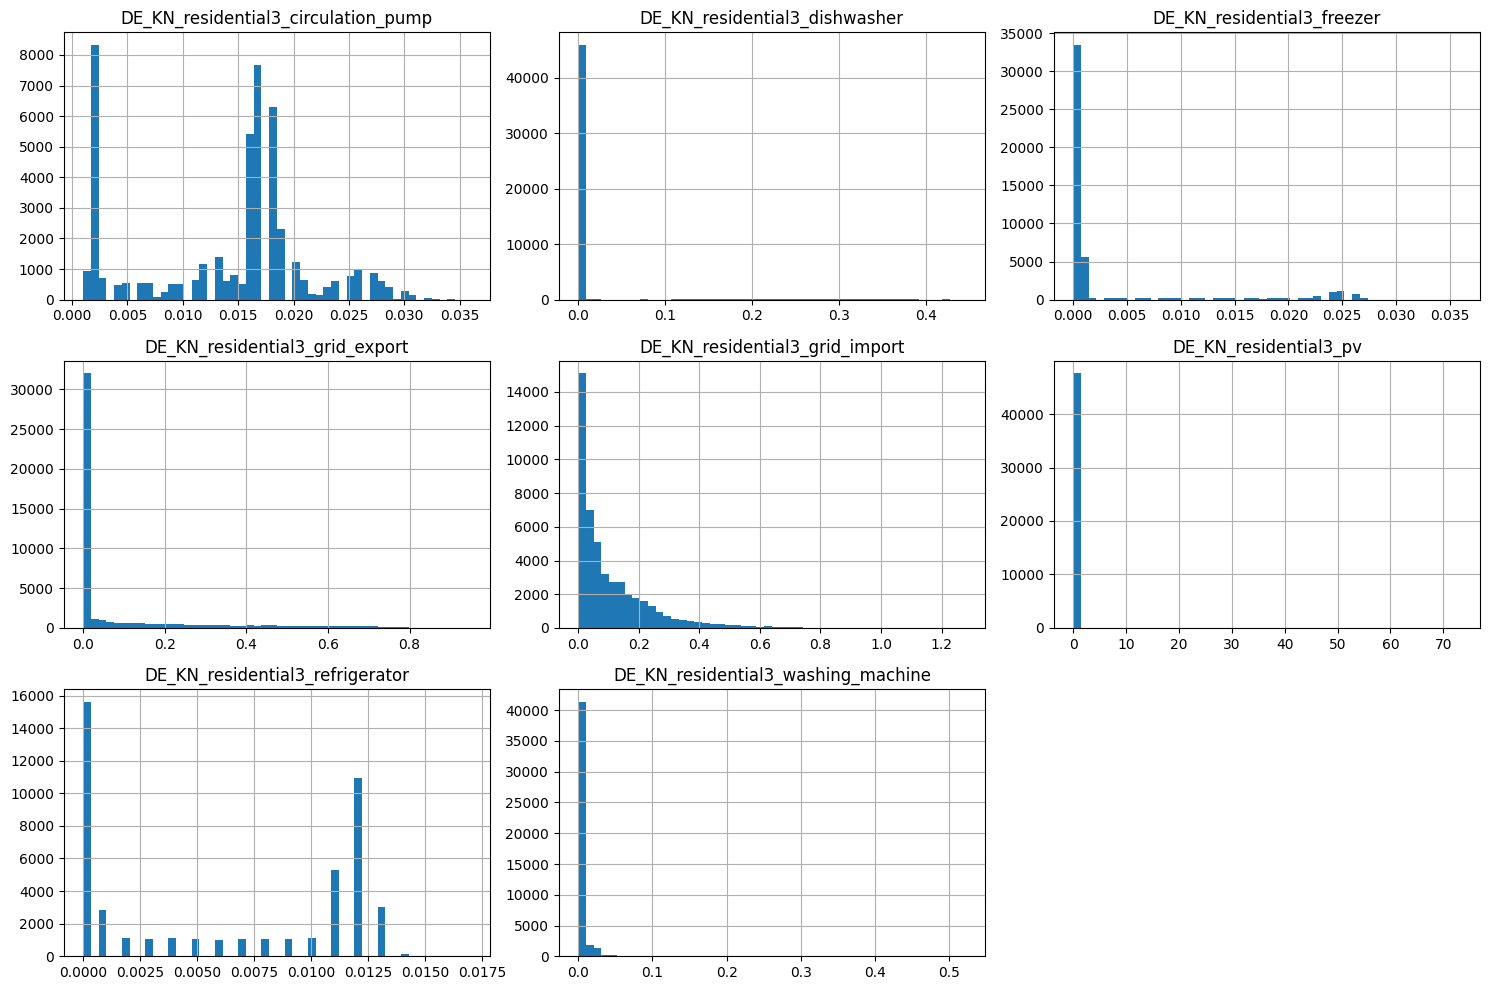

In [17]:
df_usage.hist(figsize=(15,10), bins=50)
plt.tight_layout()
plt.show()

The distributions reveal different usage behaviors across variables. Grid import is right-skewed, with many low values and occasional peaks, reflecting baseline consumption with sporadic high demand. PV generation shows a large concentration at zero, corresponding to nighttime periods, and higher values during the day. Appliances such as the washing machine and dishwasher are mostly inactive with occasional spikes, indicating event-based usage, while devices like refrigerators and pumps exhibit stable, low-level consumption.

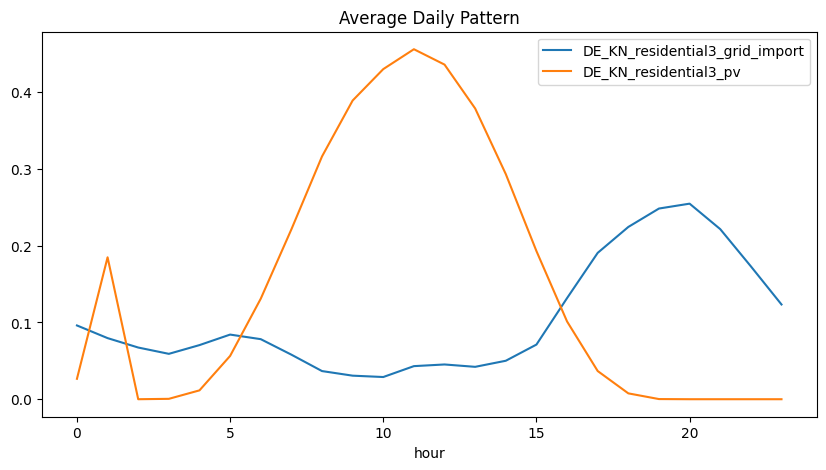

In [18]:
df_usage['hour'] = df_usage.index.hour

daily_pattern = df_usage.groupby('hour').mean()

daily_pattern[['DE_KN_residential3_grid_import',
               'DE_KN_residential3_pv']].plot(figsize=(10,5))
plt.title("Average Daily Pattern")
plt.show()

This plot shows the average behavior over a typical day. PV generation peaks around midday, while grid import reaches its highest levels in the evening. This clear mismatch indicates that energy is generated when it is not needed most, leading to continued reliance on grid electricity. The pattern highlights inefficiencies in energy usage and suggests potential for optimization.

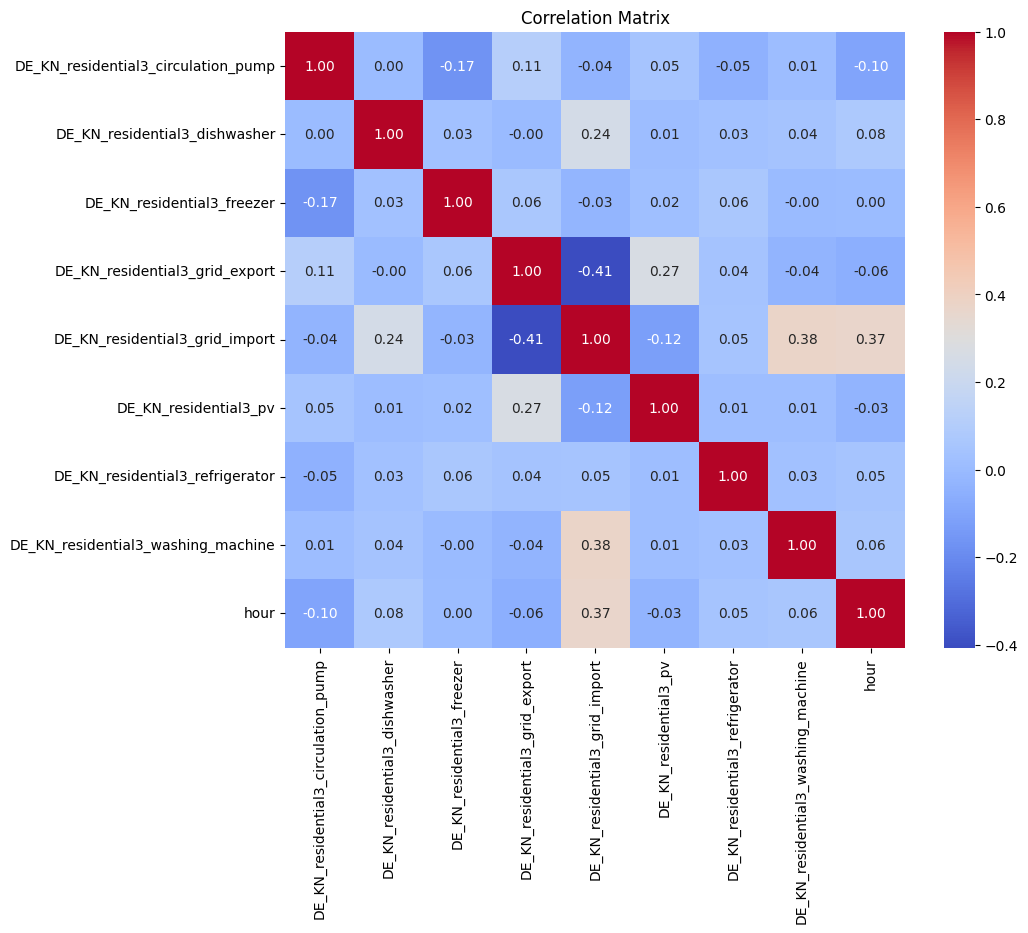

In [19]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df_usage.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

The correlation analysis shows relationships between variables. Grid import has moderate positive correlations with the washing machine and time of day, indicating that both appliance usage and daily routines influence electricity demand. A negative correlation between grid import and grid export reflects the effect of solar generation. However, the weak correlation between PV and grid import suggests that solar energy is not strongly reducing grid consumption.

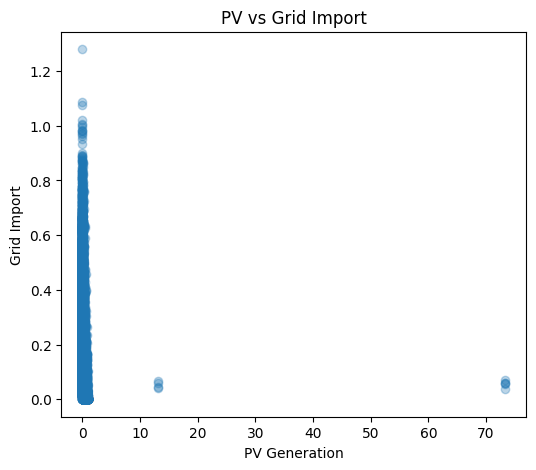

In [20]:
plt.figure(figsize=(6,5))
plt.scatter(df_usage['DE_KN_residential3_pv'],
            df_usage['DE_KN_residential3_grid_import'],
            alpha=0.3)
plt.xlabel("PV Generation")
plt.ylabel("Grid Import")
plt.title("PV vs Grid Import")
plt.show()

This scatter plot illustrates the relationship between solar generation and grid usage. Most observations occur when PV generation is zero, representing nighttime. For periods with solar output, there is no strong inverse relationship with grid import. This confirms that higher solar generation does not consistently lead to lower grid consumption, indicating limited integration of renewable energy into household usage patterns.

In [21]:
var = df_usage.var().sort_values()
print(var)

low_var = var[var < 1e-5].index
df_fs = df_usage.drop(columns=low_var)

DE_KN_residential3_refrigerator         0.000029
DE_KN_residential3_freezer              0.000054
DE_KN_residential3_circulation_pump     0.000059
DE_KN_residential3_dishwasher           0.001992
DE_KN_residential3_washing_machine      0.003710
DE_KN_residential3_grid_import          0.016379
DE_KN_residential3_grid_export          0.035925
DE_KN_residential3_pv                   0.629380
hour                                   47.920739
dtype: float64


In [22]:
zero_pct = (df_fs == 0).mean().sort_values(ascending=False)
print(zero_pct)

sparse = zero_pct[zero_pct > 0.95].index
df_fs = df_fs.drop(columns=sparse)

DE_KN_residential3_washing_machine     0.799769
DE_KN_residential3_freezer             0.702373
DE_KN_residential3_grid_export         0.645978
DE_KN_residential3_pv                  0.514577
DE_KN_residential3_dishwasher          0.329091
DE_KN_residential3_refrigerator        0.328082
DE_KN_residential3_grid_import         0.258874
hour                                   0.041672
DE_KN_residential3_circulation_pump    0.000000
dtype: float64


The variance analysis shows that system-level variables such as grid import, grid export, and PV exhibit higher variability, indicating dynamic behavior over time. Appliance-level features generally have lower variance, reflecting either stable base load consumption (e.g., refrigerator, circulation pump) or infrequent usage patterns. Low variance does not necessarily imply irrelevance, as some features represent continuous background consumption.

In [23]:
zero_pct = (df_fs == 0).mean().sort_values(ascending=False)
print(zero_pct)

sparse = zero_pct[zero_pct > 0.95].index
df_fs = df_fs.drop(columns=sparse)

DE_KN_residential3_washing_machine     0.799769
DE_KN_residential3_freezer             0.702373
DE_KN_residential3_grid_export         0.645978
DE_KN_residential3_pv                  0.514577
DE_KN_residential3_dishwasher          0.329091
DE_KN_residential3_refrigerator        0.328082
DE_KN_residential3_grid_import         0.258874
hour                                   0.041672
DE_KN_residential3_circulation_pump    0.000000
dtype: float64


The sparsity analysis reveals that several appliances, such as the washing machine and freezer, are inactive for most time intervals, indicating event-driven usage patterns. In contrast, features like the circulation pump show no sparsity, representing continuous operation. Grid import and PV exhibit moderate sparsity, reflecting their dependence on time-of-day and external conditions.

In [24]:
corr = df_fs.corr()['DE_KN_residential3_grid_import'].sort_values(ascending=False)
print(corr)

DE_KN_residential3_grid_import         1.000000
DE_KN_residential3_washing_machine     0.375683
hour                                   0.367065
DE_KN_residential3_dishwasher          0.244973
DE_KN_residential3_refrigerator        0.046704
DE_KN_residential3_freezer            -0.029293
DE_KN_residential3_circulation_pump   -0.038264
DE_KN_residential3_pv                 -0.124131
DE_KN_residential3_grid_export        -0.406839
Name: DE_KN_residential3_grid_import, dtype: float64


Correlation analysis shows that washing machine and dishwasher usage have the strongest positive relationships with grid import, indicating that these appliances contribute significantly to consumption peaks. The hour feature also shows a strong correlation, highlighting the importance of daily patterns. PV and grid export exhibit negative correlations with grid import, reflecting the influence of solar generation in reducing reliance on the grid, although the relationship is relatively weak.

In [25]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df_usage["season"] = df_usage.index.month.map(get_season)

extracting cleaned data

In [27]:
season_avg = df_usage.groupby("season")["DE_KN_residential3_grid_import"].mean()
print(season_avg)

season
Autumn    0.116358
Spring    0.099471
Summer    0.073878
Winter    0.146196
Name: DE_KN_residential3_grid_import, dtype: float64


In [28]:
season_avg_full = df_usage.groupby("season")[[
    "DE_KN_residential3_grid_import",
    "DE_KN_residential3_pv"
]].mean()

print(season_avg_full)

        DE_KN_residential3_grid_import  DE_KN_residential3_pv
season                                                       
Autumn                        0.116358               0.092416
Spring                        0.099471               0.191984
Summer                        0.073878               0.224850
Winter                        0.146196               0.031759


Seasonal analysis shows that both electricity consumption and solar generation vary significantly across seasons. Therefore, temporal features such as month are included in the model to capture seasonal effects.

In [30]:
df_day = df_usage[
    (df_usage.index.hour >= 10) & (df_usage.index.hour <= 16)
]

df_day[[
    "DE_KN_residential3_pv",
    "DE_KN_residential3_grid_export"
]].corr()

,DE_KN_residential3_pv,DE_KN_residential3_grid_export
DE_KN_residential3_pv,1.000000,0.917975
DE_KN_residential3_grid_export,0.917975,1.000000


A strong positive correlation between solar generation and grid export confirms that excess energy produced during the day is fed back into the grid rather than consumed locally. Combined with the weak relationship between solar generation and grid import, this indicates a temporal mismatch where solar energy is generated at times of low demand and therefore does not significantly reduce grid dependency.

In [35]:
df_usage["is_weekend"] = df_usage.index.dayofweek >= 5
df_usage["hour"] = df_usage.index.hour

hourly_pattern = df_usage.groupby(["is_weekend", "hour"])[
    "DE_KN_residential3_grid_import"
].mean().unstack(0)

hourly_pattern.columns = ["Weekday", "Weekend"]
print(hourly_pattern)

       Weekday   Weekend
hour                    
0     0.093087  0.103452
1     0.075051  0.090862
2     0.065494  0.071819
3     0.059300  0.058511
4     0.077424  0.052926
5     0.102778  0.037230
6     0.085774  0.059087
7     0.053270  0.069924
8     0.028775  0.056457
9     0.022501  0.051206
10    0.022708  0.044479
11    0.034673  0.064220
12    0.042130  0.053060
13    0.035180  0.059738
14    0.043103  0.067628
15    0.068883  0.076782
16    0.127704  0.141693
17    0.196321  0.175897
18    0.226210  0.219355
19    0.254153  0.233291
20    0.258834  0.243848
21    0.221711  0.220690
22    0.171703  0.176179
23    0.120557  0.130293


<Axes: xlabel='hour'>

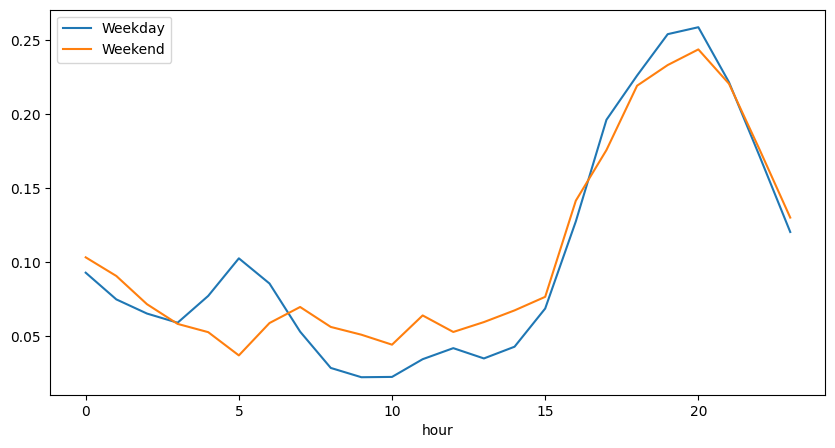

In [36]:
hourly_pattern.plot(figsize=(10,5))

The comparison between weekday and weekend consumption shows only minor differences. While weekend usage is slightly higher during midday, peak consumption in the evening is actually higher on weekdays. Overall, this indicates that electricity usage is relatively consistent and driven more by daily routines and appliance usage than by the day type.

In [26]:
df_export = df_usage.reset_index()
df_export.to_csv("residential3_cleaned.csv", index=False)